# Loading Data

In [7]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


Folder Structure:

HACKATHON

|--my_project

|----models

|------sebra_classificator

|--swissimage_annotator

|----split_data

|------train

|--------n

|----------png files without zebra crossing

|--------y

|----------png files with zebra crossing

|------val

|--------n

|----------png files without zebra crossing

|--------y

|----------png files with zebra crossing

|------test

|--------n

|----------png files without zebra crossing

|--------y

|----------png files with zebra crossing

In [ ]:
# 1. Precise relative path based on HACKATHON structure
# ../../ gets us to HACKATHON root, then we go down the other branch
data_dir = os.path.abspath("../../swissimage_annotator/split_data")

In [ ]:
# 2. Verification
if not os.path.exists(data_dir):
    print(f" Still not found at: {data_dir}")
    # Let's see what is actually in the HACKATHON folder to check spelling
    print("Folders in HACKATHON root:", os.listdir("../.."))
else:
    print(f" Path found! Loading from: {data_dir}")

 Path found! Loading from: c:\Users\deicc\Desktop\CDS_Jahr_2\4_Semester\Deep Learning\Hackathon\swissimage_annotator\split_data


In [23]:

# 3. Standard Transforms
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [24]:
# 4. Load the datasets
try:
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=data_transforms)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=data_transforms)
    test_dataset = datasets.ImageFolder(os.path.join(data_dir, 'test'), transform=data_transforms)

    print(f"\n--- Data Summary ---")
    print(f"Train images: {len(train_dataset)} ({train_dataset.classes})")
    print(f"Val images:   {len(val_dataset)}")
    print(f"Test images:  {len(test_dataset)}")
except Exception as e:
    print(f"Error loading ImageFolder: {e}")


--- Data Summary ---
Train images: 23778 (['n', 'y'])
Val images:   2400
Test images:  2400


C (Channels): 3 (Red, Green, Blue)

H (Height): 224

W (Width): 224

In [29]:
# Grab the first image and its label
img, label = train_dataset[0]

# Now you can check the shape of the tensor
print(f"Image shape (C, H, W): {img.shape}")
print(f"Label: {label}")

Image shape (C, H, W): torch.Size([3, 224, 224])
Label: 0


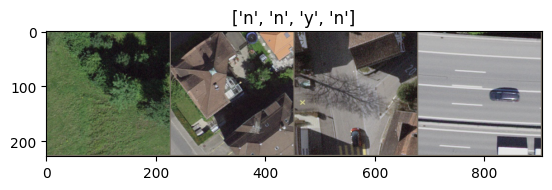

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Un-normalize using the ImageNet stats we used earlier
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Ensure values are between 0 and 1
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated

# Get a batch of training data
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
inputs, classes = next(iter(train_loader))

# Make a grid from batch
import torchvision
out = torchvision.utils.make_grid(inputs)

# Map index to class name
class_names = train_dataset.classes # ['n', 'y']
imshow(out, title=[class_names[x] for x in classes])

it seems to be correct

In [32]:
# Check if a GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# Now your weights line will work:
weight_for_y = 18546 / 5232
weights = torch.tensor([1.0, weight_for_y]).to(device)

print(f"Weights ready on {device}: [1.0, {weight_for_y:.2f}]")

Using device: cpu
Weights ready on cpu: [1.0, 3.54]


In [33]:
import torch.nn as nn
from torchvision import models

# 1. Load a pre-trained ResNet18
model = models.resnet18(weights='IMAGENET1K_V1')

# 2. Freeze the early layers (optional, but faster for Hackathons)
# This keeps the 'general' knowledge and only trains the new 'head'
for param in model.parameters():
    param.requires_grad = False

# 3. Replace the final 'Fully Connected' (fc) layer
# ResNet18's original layer has 512 inputs and 1000 outputs (for 1000 ImageNet classes)
# We change it to 2 outputs (n and y)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)

# 4. Move the whole model to your device (GPU or CPU)
model = model.to(device)

print("Model initialized and moved to device.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\deicc/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:19<00:00, 2.38MB/s]


Model initialized and moved to device.


In [34]:
import torch.optim as optim
from torch.optim import lr_scheduler
import time
import copy

# 1. Optimizer: Only train the final 'fc' layer (since we froze the rest)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# 2. Scheduler: Decay the learning rate by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

# 3. Loss Function (Using your calculated weights!)
criterion = nn.CrossEntropyLoss(weight=weights)

In [35]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Dictionary to store the loaders for easy looping
    dataloaders = {'train': train_loader, 'val': val_loader}
    dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset)}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad() # Zero the parameter gradients

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward pass + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if it's the best one yet
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

In [37]:
from torch.utils.data import DataLoader

batch_size = 32

# Create the loaders that the training function is looking for
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoaders ready. Training batches: {len(train_loader)}")

DataLoaders ready. Training batches: 744


In [38]:
# Grab one batch
inputs, labels = next(iter(train_loader))
inputs, labels = inputs.to(device), labels.to(device)

# Pass it through the model
outputs = model(inputs)
print(f"Forward pass successful! Output shape: {outputs.shape}") 
# Should be [32, 2]

Forward pass successful! Output shape: torch.Size([32, 2])


In [39]:
# Start with 10 epochs (plenty for a pre-trained ResNet on this data)
model = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------


KeyboardInterrupt: 